<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Proyecto del Curso</center></b><h2>
<h3><b><center>La aproximación de Apophis en 2029</center></b><h3>
<h7><center><i>Última actualización del profesor</b>: Viernes 6 de marzo de 2026, 7:00 am</i></center><h7>
</p>

## Enunciado

<center>
<img src="https://starwalk.space/gallery/images/apophis-size/1920x1080.jpg" align="center" width="100%"></center>

En abril de 2029 el asteroide **(99942) Apophis** tendrá [una aproximación extrema con la Tierra](https://arxiv.org/pdf/2201.12205]). Por el tamaño del asteroide, esta aproximación es considerada uno de los eventos astronómicos más importantes de esta década. En este proyecto usaremos la teoría, los métodos y los algorítmos vistos en el curso de Mecánica Celeste para estudiar la aproximación del asteroide.

El objetivo de este trabajo es que experimentes de primera mano lo que las personas expertas en mecánica celeste hacen cuando estudian las amenazas de asteroides. Aprovecha cada cosa que veas en el curso para crear un reporte científico que explore a fondo las características dinámicas de esta aproximación.

## Algunas ideas

Existen muchas maneras de aplicar la teoría que veremos en el curso en este problema y no queremos sesgar tu elección de los temas o cálculos que quieras escoger para aplicarla. Sin embargo aquí van algunas ideas de cálculos que se podrían hacer:
- Integración de la trayectoria del asteroide usando un integrador de N cuerpos y teniendo en cuenta los efectos de todos los planetas.
- Cálculo de la fecha y hora exacta de aproximación a la Tierra.
- Determinación de la distancia mínima de la órbita del asteroide a la órbita de la Tierra.
- Cálculo usando solo la teoría del problema de los dos cuerpos de la aproximación y comparación con la teoría de N cuerpos.
- Cálculo del cambio de la órbita heliocéntrica del asteroide después de su paso cerca de la Tierra.
- Aplicación de la teoría del problema de N cuerpos al asteroide.

En todos los casos debe ser evidente cómo estás usando los resultados teóricos que vemos en el curso.

## Entregables

El entregable del proyecto es **un notebook final de Jupyter** con una descripción de la teoría básica que uses, los experimentos numéricos que hayas realizado y las conclusiones a las que llegues con esos experimentos. Por supuesto puedes desarrollar otros programas y notebooks paralelos, pero se revisará el notebook con el reporte final.

Adicionalmente se deberá entregar **un repositorio de GitHub** que tenga todos los archivos, datos, notebooks, programas usados para este propósito. El notebook debe estar alojado en el repositorio.

## Criterios de evaluación

Una vez entregues el proyecto el profesor realizará una revisión del mismo y te lo devolverá con observaciones. En la segunda revisión emitirá un concepto cuantitativo del proyecto. Los criterios a evaluar serán:

- Correcta descripción y aplicación de la teoría.
- Originalidad de los experimentos numéricos.
- Conclusiones derivadas de los experimentos.
- Organización y extensión del reporte final.
- Ritmo de actualizaciones del repositorio de GitHub.

## Para tener en cuenta

- La solución presentada debe ser estrictamente individual. Evite resolver la tarea en parejas o en grupos que puede conducir a códigos o soluciones idénticos o muy similares.
- Los métodos y herramientas para resolver el problema deben ser los vistos en clase. El uso de herramientas diferentes puede ser una buena práctica en el mundo académico o laboral, pero en un curso puede también ser un indicio de un mal uso de las *asesorías* externa o del uso inapropiado de herramientas de Inteligencia Artificial (IA).
- El notebook entregado debe tener todos los resultados y gráficos, calculados y a la vista.  También debe ejecutarse completamente con `Ejecutar Todo` sin producir ningún error (verifique antes de entregar).
- El notebook debe tener explicaciones detalladas para cada paso del procedimiento usando celdas de texto. No debe poner una celda de código sin explicarla. En caso de incluir ecuaciones debe usar $\LaTeX$.

#

In [50]:
pip install -Uq pymcel

Note: you may need to restart the kernel to use updated packages.


In [51]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
import spiceypy
import astropy

### Elementos de Apophis

In [52]:

def calculate_orbital_elements(rvec, vvec, mu):
    r = np.linalg.norm(rvec)
    v = np.linalg.norm(vvec)
    hvec = np.cross(rvec, vvec)
    h = np.linalg.norm(hvec)
    evec = (np.cross(vvec, hvec) / mu) - (rvec / r)
    e = np.linalg.norm(evec)
    p = h**2 / mu
    a = p / (1 - e**2)
    Q = a * (1 + e)
    
    I = np.arccos(np.clip(hvec[2] / h, -1.0, 1.0))
    k_hat = np.array([0, 0, 1])
    nvec = np.cross(k_hat, hvec)
    n = np.linalg.norm(nvec)

    if n != 0:
        Omega = np.arccos(np.clip(nvec[0] / n, -1.0, 1.0))
        if nvec[1] < 0: Omega = 2 * np.pi - Omega
    else: Omega = 0.0

    if n != 0 and e != 0:
        dot_product_ne = np.dot(nvec, evec)
        omega = np.arccos(np.clip(dot_product_ne / (n * e), -1.0, 1.0))
        if evec[2] < 0: omega = 2 * np.pi - omega
    else: omega = 0.0

    if e != 0:
        dot_product_er = np.dot(evec, rvec)
        f = np.arccos(np.clip(dot_product_er / (e * r), -1.0, 1.0))
        if np.dot(rvec, vvec) < 0: f = 2 * np.pi - f
    else:
        f = np.arctan2(rvec[1], rvec[0])
        if f < 0: f += 2 * np.pi

    return p, e, I, Omega, omega, f, a, Q

def conic_section(p, e, I, Omega, omega, f):
    r_perifocal = p / (1 + e * np.cos(f))
    x_perifocal = r_perifocal * np.cos(f)
    y_perifocal = r_perifocal * np.sin(f)

    cO, sO = np.cos(Omega), np.sin(Omega)
    cI, sI = np.cos(I), np.sin(I)
    cw, sw = np.cos(omega), np.sin(omega)

    R11 = cO * cw - sO * sw * cI
    R12 = -cO * sw - sO * cw * cI
    R21 = sO * cw + cO * sw * cI
    R22 = -sO * sw + cO * cw * cI
    R31 = sw * sI
    R32 = cw * sI

    x_inertial = R11 * x_perifocal + R12 * y_perifocal
    y_inertial = R21 * x_perifocal + R22 * y_perifocal
    z_inertial = R31 * x_perifocal + R32 * y_perifocal

    return (x_inertial, y_inertial, z_inertial)

### Elementos orbitales Apophis

Posición (km): [-1.22506168e+10 -1.23460232e+11  6.28778039e+09]
Velocidad (km/s): [34425.50065428  2288.75271218   691.47257222]
Semi-latus rectum (p): 134779924037.91 km
Eccentricity (e): 0.1986
Inclination (I): 3.34 degrees
Right Ascension of Ascending Node (Omega): 203.92 degrees
Argument of Perigee (omega): 125.14 degrees
True Anomaly (f): 295.32 degrees
Semi-major axis (a): 140316928393.27 km = 1.0023 AU
Aphelion distance (Q): 168190490125.55 km = 1.2014 AU


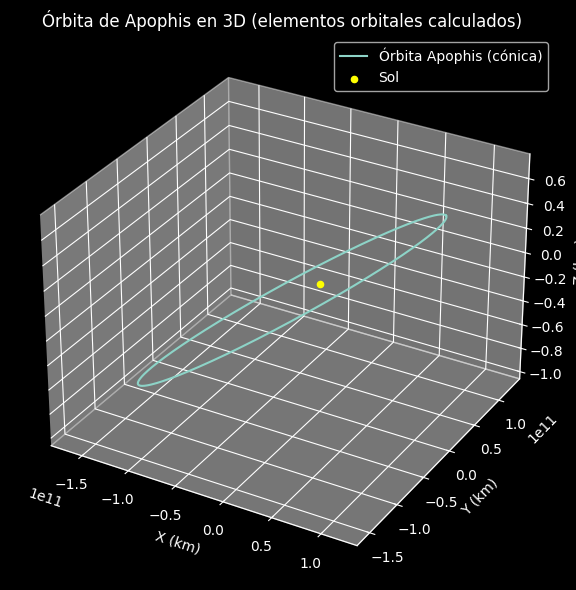

In [79]:
tabla, jd, X = pc.consulta_horizons(id='Apophis', location ='@SSB', epochs='2025-11-21')
rvec= X[:3]
vvec = X[3:]
mu=pc.constantes.mu_sun + pc.constantes.mu_earth
#magnitudes
r=np.linalg.norm(rvec)
v=np.linalg.norm(vvec)
p, e, I, Omega, omega, f, a, Q = calculate_orbital_elements(rvec, vvec, mu)
rad=180/np.pi
print(f"Posición (km): {rvec}")
print(f"Velocidad (km/s): {vvec}")
print(f"Semi-latus rectum (p): {p:.2f} km")
print(f"Eccentricity (e): {e:.4f}")
print(f"Inclination (I): {I*rad:.2f} degrees")
print(f"Right Ascension of Ascending Node (Omega): {Omega*rad:.2f} degrees")
print(f"Argument of Perigee (omega): {omega*rad:.2f} degrees")
print(f"True Anomaly (f): {f*rad:.2f} degrees")
print(f"Semi-major axis (a): {a:.2f} km = {a/1.4e11:.4f} AU")
print(f"Aphelion distance (Q): {Q:.2f} km = {Q/1.4e11:.4f} AU")

# Graficar la cónica de la órbita de Apophis
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

num_points = 500
f_arr = np.linspace(0, 2*np.pi, num_points)
x3d = []
y3d = []
z3d = []
for f_i in f_arr:
    x, y, z = conic_section(p, e, I, Omega, omega, f_i)
    x3d.append(x)
    y3d.append(y)
    z3d.append(z)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x3d, y3d, z3d, label='Órbita Apophis (cónica)')
ax.scatter([0], [0], [0], color='yellow', label='Sol')
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.legend()
plt.title('Órbita de Apophis en 3D (elementos orbitales calculados)')
plt.tight_layout()
plt.show()

### Elementos orbitales tierra

In [77]:
tabla_t, jd_t, X_t = pc.consulta_horizons(id='399', location ='@SSB', epochs='2025-11-21')
r_tierra = X_t[0:3]
rvec_t= X_t[:3]
vvec_t = X_t[3:]
mu=pc.constantes.mu_sun + pc.constantes.mu_earth
#magnitudes
r=np.linalg.norm(rvec_t)
v=np.linalg.norm(vvec_t)
p_t, e_t, I_t, Omega_t, omega_t, f_t, a_t, Q_t = calculate_orbital_elements(rvec_t, vvec_t, pc.constantes.mu_sun + pc.constantes.mu_earth)
rad=180/np.pi
print(f"Semi-latus rectum (p): {p_t:.2f} km")
print(f"Eccentricity (e): {e_t:.4f}")
print(f"Inclination (I): {I_t*rad:.2f} degrees")
print(f"Right Ascension of Ascending Node (Omega): {Omega_t*rad:.2f} degrees")
print(f"Argument of Perigee (omega): {omega_t*rad:.2f} degrees")
print(f"True Anomaly (f): {f_t*rad:.2f} degrees")
print(f"Semi-major axis (a): {a_t:.2f} km = {a_t/1.4e11 :.4f} AU")
print(f"Aphelion distance (Q): {Q_t:.2f} km = {Q_t/1.4e11:.4f} AU")

Semi-latus rectum (p): 147617753082.40 km
Eccentricity (e): 0.0126
Inclination (I): 0.01 degrees
Right Ascension of Ascending Node (Omega): 311.03 degrees
Argument of Perigee (omega): 172.59 degrees
True Anomaly (f): 294.94 degrees
Semi-major axis (a): 147641356458.32 km = 1.0546 AU
Aphelion distance (Q): 149508127584.46 km = 1.0679 AU


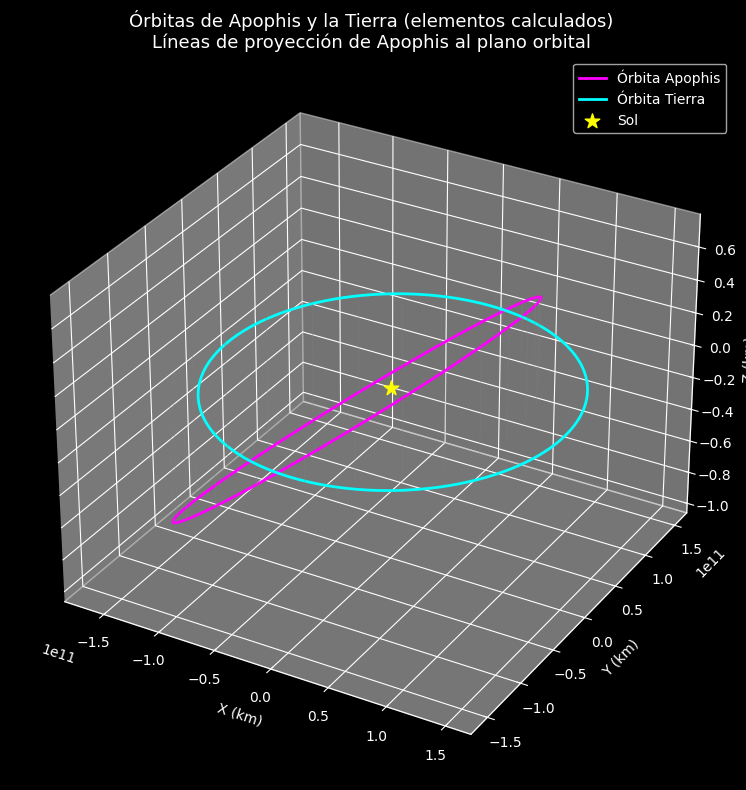

In [85]:
# Graficar órbitas de Apophis y la Tierra usando elementos calculados desde vectores
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

num_points = 500
f_arr = np.linspace(0, 2*np.pi, num_points)

# Órbita Apophis
x3d_a, y3d_a, z3d_a = [], [], []
for f_i in f_arr:
    x, y, z = conic_section(p, e, I, Omega, omega, f_i)
    x3d_a.append(x)
    y3d_a.append(y)
    z3d_a.append(z)

# Órbita Tierra
x3d_t, y3d_t, z3d_t = [], [], []
for f_i in f_arr:
    x_t, y_t, z_t = conic_section(p_t, e_t, I_t, Omega_t, omega_t, f_i)
    x3d_t.append(x_t)
    y3d_t.append(y_t)
    z3d_t.append(z_t)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Órbitas
ax.plot(x3d_a, y3d_a, z3d_a, label='Órbita Apophis', color='magenta', lw=2)
ax.plot(x3d_t, y3d_t, z3d_t, label='Órbita Tierra', color='cyan', lw=2)

# Líneas desde la órbita de Apophis al plano XY (plano orbital de la Tierra)
for i in range(0, num_points, 20):
    ax.plot([x3d_a[i], x3d_a[i]], [y3d_a[i], y3d_a[i]], [0, z3d_a[i]], color='gray', alpha=0.35, lw=0.8)

# Sol
ax.scatter([0], [0], [0], color='yellow', label='Sol', s=120, marker='*', zorder=10)

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.legend()
plt.title('Órbitas de Apophis y la Tierra (elementos calculados)\nLíneas de proyección de Apophis al plano orbital', fontsize=13)
plt.tight_layout()
plt.show()